# KNEEP_2D on Thermodynamically Consistent Lattice ABP

This notebook trains the repository's direct 2D KNEEP implementation,
`models.NEEP_K_2D.MultiScaleK_2D`, on the MIPS state point used by
`data/lattice_abp_tc/mips_demo.ipynb`.  The physical parameters are copied
unchanged: $L=16$, $G=32$, $\sigma=0.5$, $\phi=0.30$, $v_0=50$,
$D_r=1.5$, $D_t=1$, and $dt=10^{-4}$.

The model is trained **without EP labels**.  The simulator separately records
the accepted-hop medium entropy production

$$
\Delta S_{\rm med}=\frac{\mathbf v\cdot\Delta\mathbf r-\mu\Delta V}{D_t}
$$

at each departure lattice site.  Those exact pathwise increments are used only
after model selection, for held-out total and local comparisons.

Important interpretation: the default observation is occupancy only.  It hides
particle orientation and all microscopic hops between two saved frames.  Data
processing bounds the **ensemble-mean observed path KL** by the microscopic
path KL; at steady state the mean system-entropy rate vanishes, allowing a
mean-rate comparison with microscopic medium EP.  A finite-capacity two-frame
KNEEP estimate, individual pairs, cumulative finite segments, and local pixels
do not automatically obey that bound.  They are shown here as diagnostics, not
as equal labels.  Set `OBSERVATION_MODE="occupancy_polarization"` to add
$\rho\cos\theta$ and $\rho\sin\theta$ channels; `save_interval=100` still
marginalizes the intermediate path.

## 0. Environment

Run this notebook in the same CUDA-enabled environment as `mips_demo.ipynb`.
Install the packages in `data/lattice_abp_tc/requirements-l40s.txt`, install a
CUDA PyTorch wheel separately, and make sure `nvcc`, a host C++ compiler, and
Ninja are available.

Every accepted transition in this thermodynamically consistent dynamics must
have a finite log rate ratio.  The Torch, Numba, and fused CUDA samplers use
half-open inverse-CDF bins (`draw < cumulative`), so a zero-probability
direction cannot be selected even when the uniform draw is exactly zero.
Non-finite exact EP is therefore a fatal implementation or stale-cache error.
**Restart an already-running Jupyter kernel after updating the repository**,
because a previously loaded CUDA extension remains cached in that process.

In [3]:
from pathlib import Path
import hashlib
import importlib.util
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import time
import warnings
from argparse import Namespace
from datetime import datetime


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "lattice_abp_tc" / "core.py").exists():
            return path
    raise RuntimeError(
        "Could not find CNEEP_v2. Start Jupyter inside the repository or set the working directory."
    )


ROOT = find_repo_root("/home/ldh041203/projects/CNEEP_v2")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Set extension build variables before importing torch.
bootstrap_nvcc = shutil.which("nvcc.exe" if os.name == "nt" else "nvcc")
if bootstrap_nvcc and "CUDA_HOME" not in os.environ:
    os.environ["CUDA_HOME"] = str(Path(bootstrap_nvcc).resolve().parents[1])
os.environ.setdefault("TORCH_CUDA_ARCH_LIST", "8.9")
os.environ.setdefault("MAX_JOBS", str(min(8, os.cpu_count() or 1)))

required = ("numpy", "matplotlib", "tqdm", "ninja", "setuptools", "torch")
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(
        "Missing notebook packages: " + ", ".join(missing)
        + ". Install data/lattice_abp_tc/requirements-l40s.txt and CUDA PyTorch."
    )

print("repo:", ROOT)
print("python:", sys.executable)

repo: /home/ldh041203/projects/CNEEP_v2
python: /home/ldh041203/.conda/envs/jupyter-gpu/bin/python


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from torch.utils.cpp_extension import CUDA_HOME, is_ninja_available
from tqdm.auto import tqdm


if not torch.cuda.is_available():
    raise RuntimeError(
        f"CUDA is unavailable (torch={torch.__version__}, wheel CUDA={torch.version.cuda}). "
        "Select the CUDA-enabled Jupyter kernel."
    )

DEVICE = torch.device("cuda:0")
gpu = torch.cuda.get_device_properties(DEVICE)
capability = torch.cuda.get_device_capability(DEVICE)
if capability != (8, 9):
    warnings.warn(
        f"The reference target is an L40S (sm_89); found {gpu.name} "
        f"with sm_{capability[0]}{capability[1]}."
    )

nvcc_name = "nvcc.exe" if os.name == "nt" else "nvcc"
nvcc = None
if CUDA_HOME is not None:
    candidate = Path(CUDA_HOME) / "bin" / nvcc_name
    if candidate.is_file():
        nvcc = str(candidate)
if nvcc is None:
    nvcc = shutil.which(nvcc_name)
host_compiler = (
    shutil.which("cl.exe")
    if os.name == "nt"
    else (shutil.which("c++") or shutil.which("g++") or shutil.which("clang++"))
)

toolchain_errors = []
if torch.version.cuda is None:
    toolchain_errors.append("Installed PyTorch is CPU-only.")
if CUDA_HOME is None:
    toolchain_errors.append("CUDA_HOME was not detected by torch.utils.cpp_extension.")
if nvcc is None:
    toolchain_errors.append("nvcc was not found; install the CUDA Toolkit.")
if host_compiler is None:
    toolchain_errors.append("No compatible host C++ compiler was found on PATH.")
if not is_ninja_available():
    toolchain_errors.append("Ninja is unavailable.")
if toolchain_errors:
    raise RuntimeError("Fused CUDA prerequisites failed:\n- " + "\n- ".join(toolchain_errors))

from data.lattice_abp_tc._cuda_backend import (
    cuda_backend_buildable,
    load_cuda_backend,
)

if not cuda_backend_buildable():
    raise RuntimeError("The fused CUDA backend is not buildable in this kernel.")
cuda_extension = load_cuda_backend(verbose=True)

from data.lattice_abp_tc import ThermodynamicLatticeABP, ThermodynamicLatticeABPParams
from models.NEEP_K_2D import MultiScaleK_2D
zaQ
print(f"GPU: {gpu.name} ({gpu.total_memory / 2**30:.1f} GiB)")
print(f"PyTorch: {torch.__version__}, wheel CUDA: {torch.version.cuda}")
print(f"CUDA extension: {cuda_extension.__name__}")
print(f"platform: {platform.platform()}")

/home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using /home/ldh041203/.cache/torch_extensions/py312_cu124 as PyTorch extensions root...
Creating extension directory /home/ldh041203/.cache/torch_extensions/py312_cu124/lattice_abp_cuda_5fef8ea6bdae...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/ldh041203/.cache/torch_extensions/py312_cu124/lattice_abp_cuda_5fef8ea6bdae/build.ninja...
Building extension module lattice_abp_cuda_5fef8ea6bdae...
Using envvar MAX_JOBS (8) as the number of workers...


[1/3] /home/ldh041203/.conda/envs/jupyter-gpu/bin/x86_64-conda-linux-gnu-c++ -MMD -MF cuda_sweep.o.d -DTORCH_EXTENSION_NAME=lattice_abp_cuda_5fef8ea6bdae -DTORCH_API_INCLUDE_EXTENSION_H -DPYBIND11_COMPILER_TYPE=\"_gcc\" -DPYBIND11_STDLIB=\"_libstdcpp\" -DPYBIND11_BUILD_ABI=\"_cxxabi1011\" -isystem /home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/torch/include -isystem /home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/torch/include/TH -isystem /home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/torch/include/THC -isystem /tools/cuda/cuda12.4/include -isystem /home/ldh041203/.conda/envs/jupyter-gpu/include/python3.12 -D_GLIBCXX_USE_CXX11_ABI=0 -fPIC -std=c++17 -O3 -std=c++17 -c /home/ldh041203/projects/CNEEP_v2/data/lattice_abp_tc/csrc/cuda_sweep.cpp -o cuda_sweep.o 
[2/3] /tools/cuda/cuda12.4/bin/nvcc --generate-depend

Loading extension module lattice_abp_cuda_5fef8ea6bdae...


GPU: NVIDIA L40S (44.5 GiB)
PyTorch: 2.6.0+cu124, wheel CUDA: 12.4
CUDA extension: lattice_abp_cuda_5fef8ea6bdae
platform: Linux-5.15.0-94-generic-x86_64-with-glibc2.27


## 1. MIPS state point and KNEEP configuration

In [15]:
def n_from_packing_fraction(phi, box_size, sigma):
    return int(round(phi * 4.0 * box_size * box_size / (math.pi * sigma * sigma)))


# --------------------------- user switches ---------------------------
REUSE_TRAJECTORY = True
OBSERVATION_MODE = "occupancy"  # "occupancy" or "occupancy_polarization"

# ---------------- MIPS demo physical parameters: unchanged ----------------
L = 16.0
GRID_SIZE = 32
SIGMA = 0.5
PHI = 0.30
N = n_from_packing_fraction(PHI, L, SIGMA)

physics = dict(
    N=N,
    L=L,
    grid_size=GRID_SIZE,
    sigma=SIGMA,
    epsilon=1.0,
    mobility=1.0,
    v0=50.0,
    Dr=1.5,
    Dt=1.0,
    dt=1.0e-4,
    prefactor="cv",
    strict_probabilities=True,
    probability_tolerance=1.0e-6,
    shuffle_particles=True,
    seed=7,
    device=str(DEVICE),
    dtype="float32",
    backend="cuda_fused",
)

# Run all replicas together. Each replica supplies 1,000 saved intervals:
# 80 train + 20 validation + 1 held-out test trajectory.
B = 101
N_TRAIN_ENSEMBLES = 80
N_VALIDATION_ENSEMBLES = 20
N_TEST_ENSEMBLES = 1
burn_in = 100_000
n_steps = 100_000
save_interval = 100

if OBSERVATION_MODE not in {"occupancy", "occupancy_polarization"}:
    raise ValueError(f"Unknown OBSERVATION_MODE={OBSERVATION_MODE!r}")
if B != N_TRAIN_ENSEMBLES + N_VALIDATION_ENSEMBLES + N_TEST_ENSEMBLES:
    raise ValueError("B must equal train + validation + test ensemble counts.")
if N_TEST_ENSEMBLES != 1:
    raise ValueError("This notebook expects exactly one held-out test trajectory.")
if n_steps <= 0 or save_interval <= 0 or n_steps % save_interval != 0:
    raise ValueError("n_steps must be positive and divisible by save_interval.")
if n_steps // save_interval < 4:
    raise ValueError("Save at least four trajectory intervals.")

opt = Namespace()
opt.model_type = "MultiScaleK_2D"
opt.device = str(DEVICE)
opt.alpha = -0.5
opt.beta = 1.0
opt.positional = False
opt.seq_len = 2
opt.max_distance = 5
opt.include_k0 = True
opt.n_channel = 32
opt.n_hidden = 2
opt.n_components = 1 if OBSERVATION_MODE == "occupancy" else 3
opt.input_shape = (GRID_SIZE, GRID_SIZE)
opt.n_iter = 2_000
opt.train_batch_size = 256
opt.eval_batch_size = 256
opt.lr = 1.0e-4
opt.wd = 1.0e-5
opt.clip_norm = 1.0
opt.record_freq = 100
opt.seed = 3

torch.manual_seed(opt.seed)
np.random.seed(opt.seed)

dt_saved = save_interval * physics["dt"]
params = ThermodynamicLatticeABPParams(**physics)
sim = ThermodynamicLatticeABP(params)
assert sim.backend == "cuda_fused" and sim.device.type == "cuda"

RESULT_ROOT = ROOT / "results"
run_tag = datetime.now().strftime("%Y-%m-%d-%H%M%S")
current_result_folder = RESULT_ROOT / f"CorrLABP-TC-KNEEP2D-{run_tag}"
current_result_folder.mkdir(parents=True, exist_ok=False)
best_checkpoint_path = current_result_folder / "best_model_parameter.pth.tar"
current_checkpoint_path = current_result_folder / "model_parameter.pth.tar"

SAMPLER_SOURCE_FILES = (
    "data/lattice_abp_tc/core.py",
    "data/lattice_abp_tc/_numba_backend.py",
    "data/lattice_abp_tc/_cuda_backend.py",
    "data/lattice_abp_tc/csrc/cuda_sweep.cpp",
    "data/lattice_abp_tc/csrc/cuda_sweep_kernel.cu",
)
sampler_source_sha256 = hashlib.sha256(
    b"".join((ROOT / path).read_bytes() for path in SAMPLER_SOURCE_FILES)
).hexdigest()
trajectory_config = {
    "cache_version": 2,  # Exact local-EP dataset schema/source version.
    "sampler_source_sha256": sampler_source_sha256,
    "physics": {k: v for k, v in physics.items() if k != "device"},
    "B": B,
    "burn_in": burn_in,
    "n_steps": n_steps,
    "save_interval": save_interval,
}
config_json = json.dumps(trajectory_config, sort_keys=True)
cache_id = hashlib.sha256(config_json.encode("utf-8")).hexdigest()[:16]
CACHE_DIR = ROOT / "output" / "lattice_abp_tc_kneep"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
trajectory_cache = CACHE_DIR / f"trajectory_{cache_id}.pt"

print(
    f"L={params.L:g}, G={params.grid_size}, dl={params.dl:g}, N={params.N}, "
    f"phi={params.phi:.6f}, Pe={params.Pe:.3f}, gamma2={params.gamma2:.1f}"
)
print(
    f"B={B}, burn_in={burn_in}, n_steps={n_steps}, "
    f"save_interval={save_interval}, dt_saved={dt_saved:g}"
)
print(f"observation={OBSERVATION_MODE}, KNEEP components={opt.n_components}")
print("trajectory cache:", trajectory_cache)
print("results:", current_result_folder)

L=16, G=32, dl=0.5, N=391, phi=0.299893, Pe=66.667, gamma2=2500.0
B=101, burn_in=100000, n_steps=100000, save_interval=100, dt_saved=0.01
observation=occupancy, KNEEP components=1
trajectory cache: /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_kneep/trajectory_a58f2fd2c5fdf089.pt
results: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-TC-KNEEP2D-2026-08-03-073751


## 2. Equilibrated trajectory with exact local medium EP

In [16]:
# Recreate the simulator immediately before the production run so the cache
# provenance explicitly corresponds to physics["seed"] == 7.
sim = ThermodynamicLatticeABP(params)
trajectory_was_generated = False

tensor_keys = (
    "sites",
    "theta",
    "times",
    "occupancy",
    "accepted_hops",
    "exact_medium_ep",
    "exact_active_medium_ep",
    "exact_wca_medium_ep",
    "exact_medium_ep_rate",
    "exact_medium_ep_maps",
)

if REUSE_TRAJECTORY and trajectory_cache.exists():
    try:
        result = torch.load(trajectory_cache, map_location="cpu", weights_only=True)
    except TypeError:  # PyTorch < 2.0
        result = torch.load(trajectory_cache, map_location="cpu")
    missing_keys = sorted(set(tensor_keys) - set(result))
    if missing_keys:
        raise RuntimeError(f"Stale trajectory cache is missing {missing_keys}: {trajectory_cache}")
    print("loaded:", trajectory_cache)
else:
    torch.cuda.synchronize(DEVICE)
    started = time.perf_counter()
    raw_result = sim.simulate(
        B=B,
        burn_in=burn_in,
        n_steps=n_steps,
        save_interval=save_interval,
        show_progress=True,
        save_diagnostics=False,
        save_occupancy=True,
        save_exact_medium_ep=True,
        save_ep_maps=True,
    )
    torch.cuda.synchronize(DEVICE)
    elapsed = time.perf_counter() - started
    result = {key: raw_result[key] for key in tensor_keys}
    trajectory_was_generated = True
    print(
        f"simulated in {elapsed:.2f} s "
        f"({B * (burn_in + n_steps) / max(elapsed, 1e-12):.1f} ensemble sweeps/s)"
    )
    del raw_result
    torch.cuda.empty_cache()

# A valid thermodynamic trajectory must have finite exact EP everywhere.
if not bool(torch.isfinite(result["exact_medium_ep"]).all()):
    raise RuntimeError(
        "Non-finite exact EP indicates an invalid implementation or stale cache. "
        "Restart the kernel, then set REUSE_TRAJECTORY=False once to regenerate it."
    )
if not bool(torch.isfinite(result["exact_medium_ep_maps"]).all()):
    raise RuntimeError("Non-finite exact local EP map.")
assert int(result["occupancy"].min()) >= 0
assert int(result["occupancy"].max()) <= 1
assert bool((result["occupancy"].sum(dim=(-2, -1)) == params.N).all())
torch.testing.assert_close(
    result["exact_medium_ep_maps"].sum(dim=(-2, -1)).T,
    result["exact_medium_ep"],
    rtol=2.0e-5,
    atol=2.0e-4,
)
torch.testing.assert_close(
    result["exact_active_medium_ep"] + result["exact_wca_medium_ep"],
    result["exact_medium_ep"],
    rtol=2.0e-5,
    atol=2.0e-4,
)

if trajectory_was_generated:
    # A killed process can leave the temporary file, but never a partial file
    # at the canonical cache path.
    temporary_cache = trajectory_cache.with_suffix(trajectory_cache.suffix + ".tmp")
    torch.save(result, temporary_cache)
    os.replace(temporary_cache, trajectory_cache)
    print("saved:", trajectory_cache)

# Lightweight stationarity diagnostics across every replica.  These are not a
# substitute for longer seed-group/block analysis, but expose obvious drift.
exact_rate_matrix = result["exact_medium_ep_rate"].numpy()
half = max(1, exact_rate_matrix.shape[1] // 2)
early_ep_rate = exact_rate_matrix[:, :half].mean(axis=1)
late_ep_rate = exact_rate_matrix[:, half:].mean(axis=1)
overall_ep_rate = exact_rate_matrix.mean(axis=1)
relative_ep_drift = np.abs(late_ep_rate - early_ep_rate) / np.maximum(
    np.abs(overall_ep_rate), 1.0e-12
)
initial_mips = [
    sim.mips_summary(result["occupancy"][0, replica], include_coarse=False)
    for replica in range(B)
]
final_mips = [
    sim.mips_summary(result["occupancy"][-1, replica], include_coarse=False)
    for replica in range(B)
]
stationarity = {
    "early_exact_medium_ep_rate": early_ep_rate.tolist(),
    "late_exact_medium_ep_rate": late_ep_rate.tolist(),
    "relative_exact_ep_drift": relative_ep_drift.tolist(),
    "initial_largest_site_cluster_fraction": [
        item["largest_site_cluster_fraction"] for item in initial_mips
    ],
    "final_largest_site_cluster_fraction": [
        item["largest_site_cluster_fraction"] for item in final_mips
    ],
    "initial_low_k_ratio": [item["low_k_ratio"] for item in initial_mips],
    "final_low_k_ratio": [item["low_k_ratio"] for item in final_mips],
}
if float(relative_ep_drift.max()) > 0.25:
    warnings.warn(
        "At least one replica has >25% early/late mean EP-rate drift. "
        "Increase burn_in/production and use a new cache before interpreting NESS rates."
    )

print("sites:", tuple(result["sites"].shape))
print("occupancy:", tuple(result["occupancy"].shape))
print("exact total EP:", tuple(result["exact_medium_ep"].shape))
print("exact local EP:", tuple(result["exact_medium_ep_maps"].shape))
print("mean exact medium EP rate:", result["exact_medium_ep_rate"].mean(dim=1).numpy())
print("relative early/late EP-rate drift:", relative_ep_drift)
print("initial largest-cluster fractions:", stationarity["initial_largest_site_cluster_fraction"])
print("final largest-cluster fractions:", stationarity["final_largest_site_cluster_fraction"])
print("initial low-k ratios:", stationarity["initial_low_k_ratio"])
print("final low-k ratios:", stationarity["final_low_k_ratio"])

loaded: /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_kneep/trajectory_a58f2fd2c5fdf089.pt
sites: (1001, 101, 391, 2)
occupancy: (1001, 101, 32, 32)
exact total EP: (101, 1000)
exact local EP: (1000, 101, 32, 32)
mean exact medium EP rate: [105901.77  134445.5   129782.94  124015.54  100085.1   107334.06
 130707.43  112653.82  134063.94  144870.58  141827.83  130423.
 134780.53  109730.05  141801.45  110320.41  135661.16  134394.28
 132820.95  131002.93  121579.14  135750.81  134691.9   110291.32
 140829.19  143848.39  105408.45  141342.4   118439.    132727.84
  99964.33  104832.734 131295.44  135798.73  137871.11  129753.57
 109361.2   141675.58  145264.31  135219.27  138304.39  144678.72
 146506.14  123472.22  102249.85  128226.37  138276.27  136732.5
 134369.58  107672.13  135793.7   135406.53   98871.08  139496.75
 136706.06  104941.17  131938.72  126216.26   94976.73  102977.88
  99965.7   106577.42  130502.29  139681.81  107735.914 135571.75
 129614.77  139413.98  1388

## 3. Observed fields and ensemble split

Arrays from the simulator are time-major.  KNEEP uses
`[ensemble, time, component, x, y]`.  The exact map is changed from
`[time_pair, ensemble, x, y]` to `[ensemble, time_pair, x, y]` with the same
pair index.

The split is by replica, not by neighboring frames: replicas 0--79 are used for
training, 80--99 for validation, and replica 100 is the single held-out test
trajectory.  Its exact EP never enters training or checkpoint selection. Fused
CUDA uses independent initial states and uniform draws across `B`, but shares
each sweep's particle permutation. Use a new simulator seed/cache for fully
independent repeat-level error bars.

In [17]:
def encode_observed_fields(simulation_result, mode):
    occupancy = simulation_result["occupancy"].float()  # [T,B,G,G]
    if mode == "occupancy":
        return occupancy.permute(1, 0, 2, 3).unsqueeze(2).contiguous()
    if mode != "occupancy_polarization":
        raise ValueError(f"Unknown OBSERVATION_MODE={mode!r}")

    sites = simulation_result["sites"].long()            # [T,B,N,2]
    theta = simulation_result["theta"].float()           # [T,B,N]
    T, B_here, _, _ = sites.shape
    linear = sites[..., 0] * GRID_SIZE + sites[..., 1]
    pol_x = torch.zeros((T, B_here, GRID_SIZE * GRID_SIZE), dtype=torch.float32)
    pol_y = torch.zeros_like(pol_x)
    pol_x.scatter_add_(2, linear, torch.cos(theta))
    pol_y.scatter_add_(2, linear, torch.sin(theta))
    pol_x = pol_x.view(T, B_here, GRID_SIZE, GRID_SIZE)
    pol_y = pol_y.view(T, B_here, GRID_SIZE, GRID_SIZE)
    fields = torch.stack((occupancy, pol_x, pol_y), dim=2)
    return fields.permute(1, 0, 2, 3, 4).contiguous()


observed = encode_observed_fields(result, OBSERVATION_MODE)
# The cache already contains these raw tensors; the remaining notebook uses the
# encoded fields, so release roughly 0.8 GiB at B=101.
result.pop("sites")
result.pop("theta")
gt_local_all = result["exact_medium_ep_maps"].permute(1, 0, 2, 3).contiguous()
gt_total_all = result["exact_medium_ep"]

assert observed.shape[:2] == (B, n_steps // save_interval + 1)
assert observed.shape[2:] == (opt.n_components, GRID_SIZE, GRID_SIZE)
assert gt_local_all.shape[:2] == (B, observed.shape[1] - 1)
torch.testing.assert_close(
    gt_local_all.sum(dim=(-2, -1)), gt_total_all, rtol=2.0e-5, atol=2.0e-4
)

train_ensemble_ids = torch.arange(0, N_TRAIN_ENSEMBLES)
val_ensemble_ids = torch.arange(
    N_TRAIN_ENSEMBLES,
    N_TRAIN_ENSEMBLES + N_VALIDATION_ENSEMBLES,
)
test_ensemble_ids = torch.tensor([B - 1])
assert len(train_ensemble_ids) == 80
assert len(val_ensemble_ids) == 20
assert test_ensemble_ids.tolist() == [100]

# Contiguous slices stay as views and avoid duplicating the large field tensor.
train_video = observed[:N_TRAIN_ENSEMBLES]
val_video = observed[
    N_TRAIN_ENSEMBLES : N_TRAIN_ENSEMBLES + N_VALIDATION_ENSEMBLES
]
test_video = observed[-N_TEST_ENSEMBLES:]
gt_local_test = gt_local_all[-N_TEST_ENSEMBLES:]
gt_total_test = gt_total_all[-N_TEST_ENSEMBLES:]

channel_mean = train_video.mean(dim=(0, 1, 3, 4), keepdim=True)
channel_std = train_video.std(dim=(0, 1, 3, 4), keepdim=True).clamp_min(1.0e-6)


def normalize_pairs(x):
    return (x - channel_mean) / channel_std


print("observed:", tuple(observed.shape))
print("train/val/test replicas:", train_ensemble_ids.tolist(), val_ensemble_ids.tolist(), test_ensemble_ids.tolist())
print("channel mean:", channel_mean.flatten().numpy())
print("channel std:", channel_std.flatten().numpy())

observed: (101, 1001, 1, 32, 32)
train/val/test replicas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79] [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99] [100]
channel mean: [0.38183594]
channel std: [0.48583665]


## 4. KNEEP_2D model and unsupervised objective

In [39]:
opt.lr = 1e-2
opt.wd = 1e-5
opt.n_iter = 5000
opt.model_type = "MultiScaleK_2D"
opt.k_kernel_geometry = "Euclidean" 
from models.NEEP_K_2DF import MultiScaleK_2DF

# Make model initialization and random pair batches independent of whether the
# trajectory was simulated or loaded from cache.
torch.manual_seed(opt.seed)
np.random.seed(opt.seed)
torch.cuda.manual_seed_all(opt.seed)
model = MultiScaleK_2DF(opt).to(opt.device)
optimizer = torch.optim.AdamW(model.parameters(), lr=opt.lr, weight_decay=opt.wd)
print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")


def make_pair_batch(video, ensemble_idx, time_idx):
    x0 = video[ensemble_idx, time_idx]
    x1 = video[ensemble_idx, time_idx + 1]
    x = torch.stack((x0, x1), dim=1)
    x = normalize_pairs(x)
    if opt.n_components == 1:
        x = x.squeeze(2)  # MultiScaleK_2D expects [batch,time,x,y] for one component.
    return x.to(opt.device, non_blocking=True)


def random_pair_batch(video, batch_size):
    ensemble_idx = torch.randint(video.shape[0], (batch_size,))
    time_idx = torch.randint(video.shape[1] - 1, (batch_size,))
    return make_pair_batch(video, ensemble_idx, time_idx)


def ordered_pair_batches(video, batch_size):
    n_pairs = video.shape[1] - 1
    flat = torch.arange(video.shape[0] * n_pairs)
    for start in range(0, len(flat), batch_size):
        ids = flat[start : start + batch_size]
        yield ids // n_pairs, ids % n_pairs


def alpha_neep_loss(score, alpha):
    if alpha == 0:
        return (-score + torch.exp(-score) - 1.0).mean()
    return (
        -(torch.exp(alpha * score) - 1.0) / alpha
        + (torch.exp(-(1.0 + alpha) * score) - 1.0) / (1.0 + alpha)
    ).mean()


@torch.no_grad()
def evaluate_objective(video):
    model.eval()
    total = 0.0
    count = 0
    for ensemble_idx, time_idx in ordered_pair_batches(video, opt.eval_batch_size):
        x = make_pair_batch(video, ensemble_idx, time_idx)
        score = model(x).sum(dim=1)
        batch_loss = alpha_neep_loss(score, opt.alpha)
        total += float(batch_loss) * len(x)
        count += len(x)
    return total / max(count, 1)


# Model API and antisymmetry invariant check before training.
model.eval()
with torch.no_grad():
    x_check = random_pair_batch(train_video, min(2, opt.train_batch_size))
    j_check = model(x_check)
    maps_check = model(x_check, return_maps=True)
    assert j_check.shape == (len(x_check), opt.max_distance + 1)
    assert maps_check.shape == (len(x_check), opt.max_distance + 1, GRID_SIZE, GRID_SIZE)
    torch.testing.assert_close(j_check, maps_check.mean(dim=(-2, -1)), rtol=2e-5, atol=2e-6)
    torch.testing.assert_close(
        model(torch.flip(x_check, dims=[1]), return_maps=True),
        -maps_check,
        rtol=2e-5,
        atol=2e-6,
    )
print("KNEEP shape/antisymmetry check passed")

model parameters: 35,270
KNEEP shape/antisymmetry check passed


KNEEP training:   0%|                                                               | 3/5000 [00:04<1:44:25,  1.25s/it]

iter=    1 train=-3.092352e-03 val=+1.060086e-02 best=+1.060086e-02


KNEEP training:   2%|█▏                                                           | 101/5000 [00:17<1:01:40,  1.32it/s]

iter=  100 train=-2.344859e-01 val=-2.185608e-01 best=-2.185608e-01


KNEEP training:   4%|██▌                                                            | 201/5000 [00:30<55:29,  1.44it/s]

...

KNEEP training:  98%|████████████████████████████████████████████████████████████▊ | 4902/5000 [10:14<00:41,  2.35it/s]

iter= 4900 train=-9.271834e-01 val=-9.350066e-01 best=-9.906941e-01


KNEEP training: 100%|██████████████████████████████████████████████████████████████| 5000/5000 [10:27<00:00,  7.97it/s]

iter= 5000 train=-1.061169e+00 val=-9.324731e-01 best=-9.906941e-01


loaded best checkpoint from iteration 4600


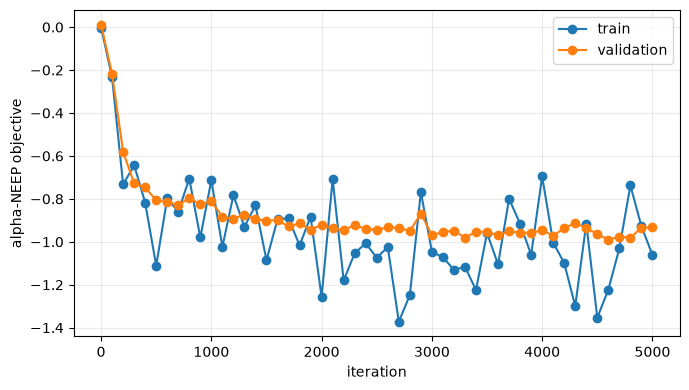

In [40]:
best_val_loss = float("inf")
history_iter = []
history_train = []
history_val = []

for iteration in tqdm(range(1, opt.n_iter + 1), desc="KNEEP training"):
    model.train()
    x = random_pair_batch(train_video, opt.train_batch_size)
    score_density = model(x).sum(dim=1)
    loss = alpha_neep_loss(score_density, opt.alpha)
    if not bool(torch.isfinite(loss)):
        raise FloatingPointError(f"non-finite training loss at iteration {iteration}")

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), opt.clip_norm)
    optimizer.step()

    if iteration == 1 or iteration % opt.record_freq == 0 or iteration == opt.n_iter:
        val_loss = evaluate_objective(val_video)
        if not math.isfinite(val_loss):
            raise FloatingPointError(f"non-finite validation loss at iteration {iteration}")
        history_iter.append(iteration)
        history_train.append(float(loss.detach().cpu()))
        history_val.append(val_loss)

        state = {
            "settings": vars(opt),
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "iteration": iteration,
            "train_loss": history_train[-1],
            "val_loss": val_loss,
            "channel_mean": channel_mean,
            "channel_std": channel_std,
            "physics": physics,
            "trajectory_config": trajectory_config,
            "observation_mode": OBSERVATION_MODE,
        }
        torch.save(state, current_checkpoint_path)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(state, best_checkpoint_path)

        print(
            f"iter={iteration:5d} train={history_train[-1]:+.6e} "
            f"val={val_loss:+.6e} best={best_val_loss:+.6e}"
        )

checkpoint = torch.load(best_checkpoint_path, map_location=opt.device, weights_only=False)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print(f"loaded best checkpoint from iteration {checkpoint['iteration']}")
if checkpoint["val_loss"] >= -1.0e-6:
    warnings.warn(
        "Best validation objective did not improve meaningfully over the zero-score baseline (0). "
        "Treat downstream EP plots as a failed-learning diagnostic."
    )

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_iter, history_train, "o-", label="train")
ax.plot(history_iter, history_val, "o-", label="validation")
ax.set_xlabel("iteration")
ax.set_ylabel("alpha-NEEP objective")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(current_result_folder / "training_loss.png", dpi=160)
plt.show()

## 5. Held-out prediction and exact-map alignment

`MultiScaleK_2D` returns the spatial **mean** of each branch map.  This notebook
uses the lattice-site convention from the existing lattice notebooks:

```text
predicted local increment at site = sum_k map_k
predicted total increment         = sum_sites predicted local increment
                                  = G^2 * sum_k J_k
```

The exact simulator map is already an increment per departure site, so no
$d\ell^2$ factor is inserted.  Dividing either map by `dt_saved` gives the
per-site rate.  If a physical-area density is desired, divide both maps by
$d\ell^2$ as a separate unit conversion.  Training the intensive spatial mean
and restoring $G^2$ afterward follows this repository's KNEEP convention; the
rescaling alone is not a proof that the finite-network output is a rigorous
full-field variational bound.

In [41]:
@torch.no_grad()
def predict_local_maps(video):
    model.eval()
    chunks = []
    for ensemble_idx, time_idx in tqdm(
        ordered_pair_batches(video, opt.eval_batch_size),
        total=math.ceil(video.shape[0] * (video.shape[1] - 1) / opt.eval_batch_size),
        desc="held-out maps",
    ):
        x = make_pair_batch(video, ensemble_idx, time_idx)
        branch_maps = model(x, return_maps=True)
        chunks.append(branch_maps.detach().cpu())
    return torch.cat(chunks, dim=0)


pred_branch_maps = predict_local_maps(test_video)  # [Npair,K,G,G]
expected_test_pairs = test_video.shape[0] * (test_video.shape[1] - 1)
assert pred_branch_maps.shape == (
    expected_test_pairs,
    opt.max_distance + 1,
    GRID_SIZE,
    GRID_SIZE,
)
assert bool(torch.isfinite(pred_branch_maps).all())
pred_local_inc = pred_branch_maps.sum(dim=1)
pred_total_inc = pred_local_inc.sum(dim=(-2, -1))

gt_local_inc = gt_local_test.reshape(-1, GRID_SIZE, GRID_SIZE)
gt_total_inc = gt_total_test.reshape(-1)
# torch.testing.assert_close(
#     gt_local_inc.sum(dim=(-2, -1)), gt_total_inc, rtol=2.0e-5, atol=2.0e-4
# )
# torch.testing.assert_close(
#     pred_branch_maps.mean(dim=(-2, -1)).sum(dim=1) * GRID_SIZE**2,
#     pred_total_inc,
#     rtol=2.0e-5,
#     atol=2.0e-4,
# )

pred_total_rate = pred_total_inc.numpy() / dt_saved
gt_total_rate = gt_total_inc.numpy() / dt_saved
pred_local_rate = pred_local_inc.numpy() / dt_saved
gt_local_rate = gt_local_inc.numpy() / dt_saved
assert np.isfinite(pred_total_rate).all()
assert np.isfinite(gt_total_rate).all()
assert np.isfinite(pred_local_rate).all()
assert np.isfinite(gt_local_rate).all()
if float(pred_total_rate.mean()) <= 0.0:
    warnings.warn("Held-out mean KNEEP score is non-positive; training did not resolve positive irreversibility.")


def comparison_metrics(target, prediction):
    target = np.asarray(target, dtype=np.float64)
    prediction = np.asarray(prediction, dtype=np.float64)
    if target.shape != prediction.shape:
        raise ValueError(f"metric shape mismatch: {target.shape} != {prediction.shape}")
    if not (np.isfinite(target).all() and np.isfinite(prediction).all()):
        raise ValueError("comparison_metrics received non-finite values")
    residual = prediction - target
    denom = np.sum((target - target.mean()) ** 2)
    correlation = (
        float(np.corrcoef(target, prediction)[0, 1])
        if len(target) > 1 and target.std() > 0 and prediction.std() > 0
        else float("nan")
    )
    return {
        "count": int(len(target)),
        "target_mean": float(target.mean()),
        "prediction_mean": float(prediction.mean()),
        "mean_ratio": float(prediction.mean() / target.mean()) if target.mean() != 0 else float("nan"),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": float(np.sqrt(np.mean(residual**2))),
        "pearson_r": correlation,
        "raw_r2": float(1.0 - np.sum(residual**2) / denom) if denom > 0 else float("nan"),
    }


total_metrics = comparison_metrics(gt_total_rate, pred_total_rate)
test_objective = evaluate_objective(test_video)
print(json.dumps(total_metrics, indent=2))
print(f"held-out alpha-NEEP objective: {test_objective:+.6e} (zero-score baseline: 0)")

held-out maps:   0%|                                                                             | 0/4 [00:00<?, ?it/s]

held-out maps: 100%|█████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 29.64it/s]


{
  "count": 1000,
  "target_mean": 140333.6092578125,
  "prediction_mean": 142306.61269213867,
  "mean_ratio": 1.0140593792517762,
  "mae": 141392.95422192384,
  "rmse": 178597.6314548613,
  "pearson_r": 0.07939920343403402,
  "raw_r2": -50.54615170512338
}
held-out alpha-NEEP objective: -1.139848e+00 (zero-score baseline: 0)


## 6. Total medium EP: held-out time series, cumulative value, and scatter

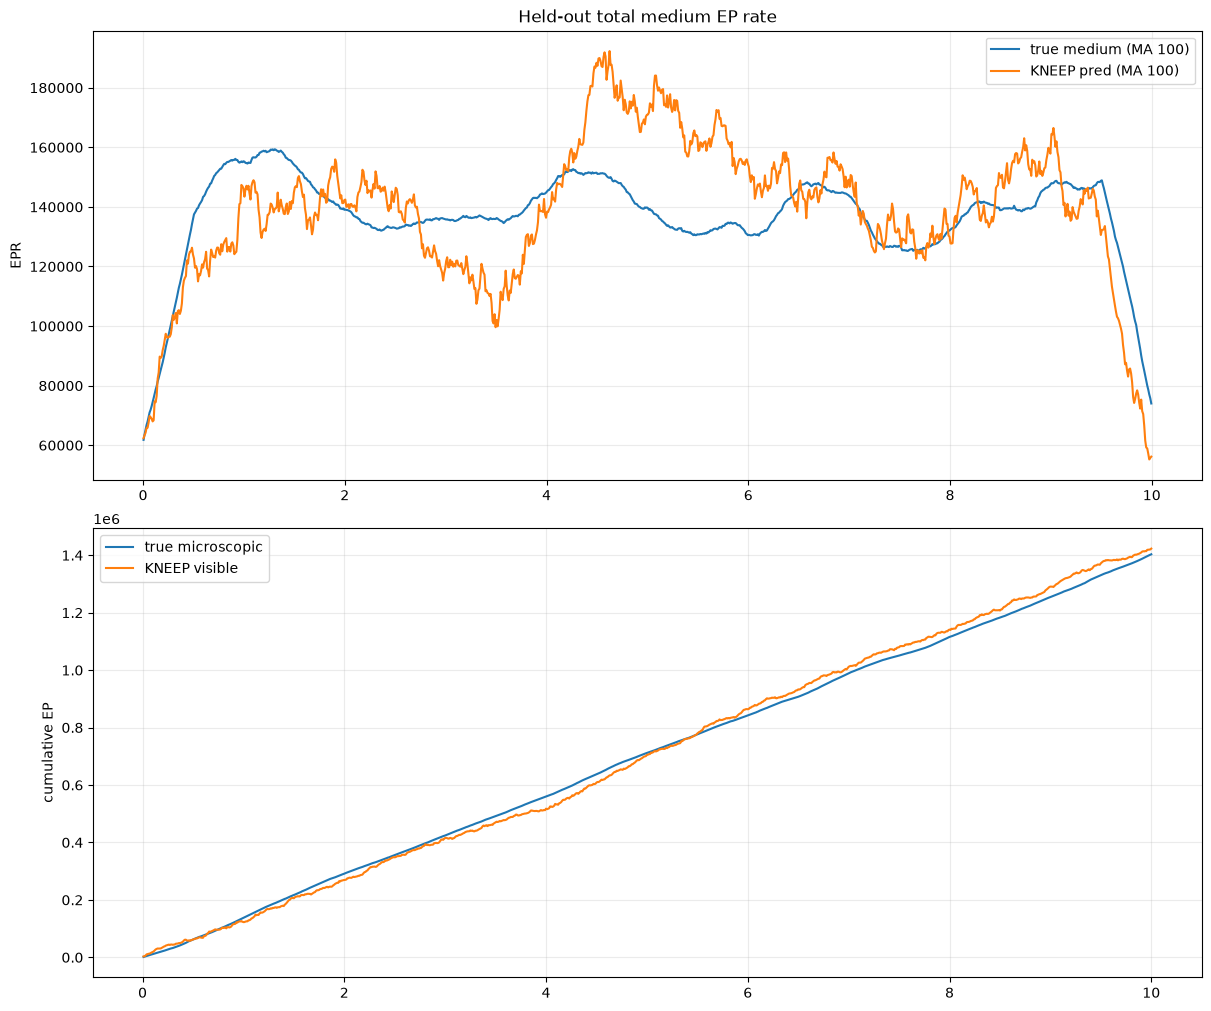

In [51]:
def moving_average(values, window):
    values = np.asarray(values)
    if len(values) == 0:
        return values
    window = max(1, min(int(window), len(values)))
    return np.convolve(values, np.ones(window) / window, mode="same")


n_pairs_per_test_replica = test_video.shape[1] - 1
time_mid = result["times"][:-1].numpy() + 0.5 * dt_saved
time_end = result["times"][1:].numpy()
plot_slice = slice(0, n_pairs_per_test_replica)  # first held-out replica
smooth_window = min(100, max(1, n_pairs_per_test_replica // 10))

fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)
axes[0].plot(
    time_mid,
    moving_average(gt_total_rate[plot_slice], smooth_window),
    label=f"true medium (MA {smooth_window})",
)
axes[0].plot(
    time_mid,
    moving_average(pred_total_rate[plot_slice], smooth_window),
    label=f"KNEEP pred (MA {smooth_window})",
)
axes[0].set_ylabel("EPR")
axes[0].set_title("Held-out total medium EP rate")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(time_end, np.cumsum(gt_total_inc.numpy()[plot_slice]), label="true microscopic")
axes[1].plot(time_end, np.cumsum(pred_total_inc.numpy()[plot_slice]), label="KNEEP visible")
axes[1].set_ylabel("cumulative EP")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.savefig(current_result_folder / "total_medium_ep_comparison.png", dpi=160)
plt.show()

## 7. True versus learned local medium EP

The true map uses the simulator's **departure-site gauge**.  The learned map is
localized by the convolution center and may choose a different gauge while
preserving a similar total.  Therefore the notebook shows a single interval,
the held-out time average, residuals, and pixelwise metrics; the total and
cumulative comparisons above remain the gauge-robust diagnostics.  Pixel R2 is
only a gauge-dependent localization diagnostic, and the absolute time-mean map
can also reflect pinning or drift of the periodic MIPS cluster.

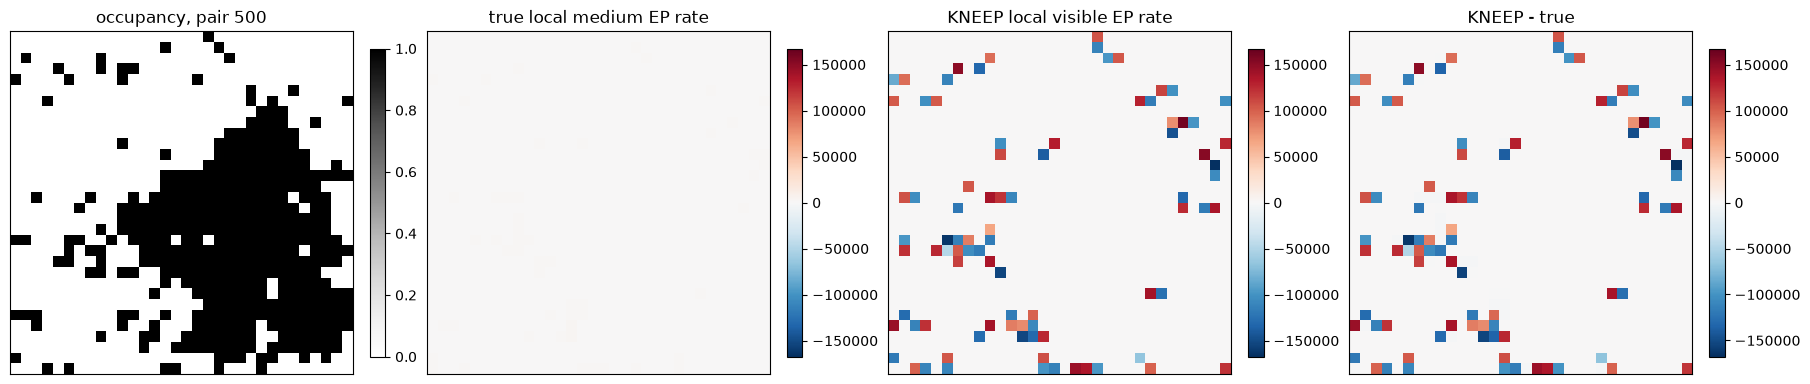

single-pair pixel metrics:
{
  "count": 1024,
  "target_mean": 130.01309430599213,
  "prediction_mean": 52.4290771484375,
  "mean_ratio": 0.4032599749148584,
  "mae": 9797.574761748314,
  "rmse": 34220.86640459083,
  "pearson_r": -0.484567319936905,
  "raw_r2": -4534.007047719125
}


In [43]:
sample_index = n_pairs_per_test_replica // 2
test_replica_original = int(test_ensemble_ids[0])
occupancy_sample = result["occupancy"][sample_index, test_replica_original].numpy()
true_sample = gt_local_rate[sample_index]
pred_sample = pred_local_rate[sample_index]
residual_sample = pred_sample - true_sample

vmax = max(float(np.abs(true_sample).max()), float(np.abs(pred_sample).max()), 1.0e-12)
residual_vmax = max(float(np.abs(residual_sample).max()), 1.0e-12)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)
im0 = axes[0].imshow(occupancy_sample.T, origin="lower", cmap="Greys", vmin=0, vmax=1)
axes[0].set_title(f"occupancy, pair {sample_index}")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(true_sample.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("true local medium EP rate")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(pred_sample.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("KNEEP local visible EP rate")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

im3 = axes[3].imshow(
    residual_sample.T,
    origin="lower",
    cmap="RdBu_r",
    vmin=-residual_vmax,
    vmax=residual_vmax,
)
axes[3].set_title("KNEEP - true")
fig.colorbar(im3, ax=axes[3], shrink=0.8)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig(current_result_folder / "local_medium_ep_single_pair.png", dpi=170)
plt.show()

single_local_metrics = comparison_metrics(true_sample.ravel(), pred_sample.ravel())
print("single-pair pixel metrics:")
print(json.dumps(single_local_metrics, indent=2))

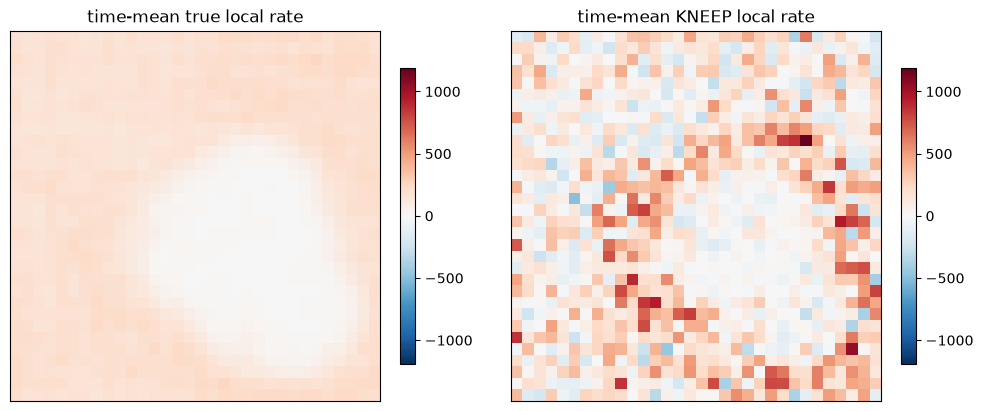

time-mean pixel metrics:
{
  "count": 1024,
  "target_mean": 137.04454079383868,
  "prediction_mean": 138.9713027141479,
  "mean_ratio": 1.014059384701852,
  "mae": 176.84725531937875,
  "rmse": 236.94810230336276,
  "pearson_r": 0.0978407727120108,
  "raw_r2": -9.683532465473288
}


In [47]:
true_mean_map = gt_local_rate[:n_pairs_per_test_replica].mean(axis=0)
pred_mean_map = pred_local_rate[:n_pairs_per_test_replica].mean(axis=0)
mean_residual = pred_mean_map - true_mean_map
mean_local_metrics = comparison_metrics(true_mean_map.ravel(), pred_mean_map.ravel())

vmax = max(float(np.abs(true_mean_map).max()), float(np.abs(pred_mean_map).max()), 1.0e-12)
residual_vmax = max(float(np.abs(mean_residual).max()), 1.0e-12)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im0 = axes[0].imshow(true_mean_map.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title("time-mean true local rate")
fig.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].imshow(pred_mean_map.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("time-mean KNEEP local rate")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig(current_result_folder / "local_medium_ep_time_mean.png", dpi=170)
plt.show()

print("time-mean pixel metrics:")
print(json.dumps(mean_local_metrics, indent=2))

## 8. K-shell contribution spectrum and saved diagnostics

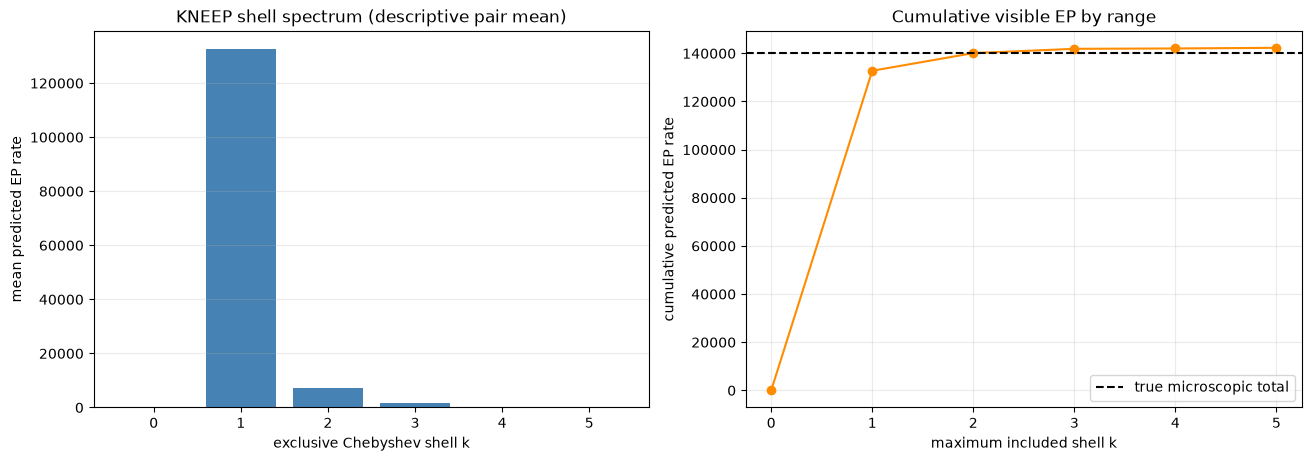

{
  "model": "MultiScaleK_2D",
  "observation_mode": "occupancy",
  "physics": {
    "N": 391,
    "L": 16.0,
    "grid_size": 32,
    "sigma": 0.5,
    "epsilon": 1.0,
    "mobility": 1.0,
    "v0": 50.0,
    "Dr": 1.5,
    "Dt": 1.0,
    "dt": 0.0001,
    "prefactor": "cv",
    "strict_probabilities": true,
    "probability_tolerance": 1e-06,
    "shuffle_particles": true,
    "seed": 7,
    "device": "cuda:0",
    "dtype": "float32",
    "backend": "cuda_fused",
    "actual_phi": 0.29989324403164286,
    "dl": 0.5,
    "Pe": 66.66666666666667
  },
  "trajectory_config": {
    "cache_version": 2,
    "sampler_source_sha256": "78fa988ac89f2dd515605fd4a83b68aa9eccffe62503247888b611cd1d0fa4dc",
    "physics": {
      "N": 391,
      "L": 16.0,
      "grid_size": 32,
      "sigma": 0.5,
      "epsilon": 1.0,
      "mobility": 1.0,
      "v0": 50.0,
      "Dr": 1.5,
      "Dt": 1.0,
      "dt": 0.0001,
      "prefactor": "cv",
      "strict_probabilities": true,
      "probability_toleran

In [45]:
# Branch maps use the same per-site convention; sum sites and divide by dt_saved.
branch_total_rates = pred_branch_maps.sum(dim=(-2, -1)).numpy() / dt_saved
mean_branch_rate = branch_total_rates.mean(axis=0)
distances = np.arange(0 if opt.include_k0 else 1, opt.max_distance + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].bar(distances, mean_branch_rate, color="steelblue")
axes[0].set_xlabel("exclusive Chebyshev shell k")
axes[0].set_ylabel("mean predicted EP rate")
axes[0].set_title("KNEEP shell spectrum (descriptive pair mean)")
axes[0].set_xticks(distances)
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(distances, np.cumsum(mean_branch_rate), "o-", color="darkorange")
axes[1].axhline(gt_total_rate.mean(), color="black", ls="--", label="true microscopic total")
axes[1].set_xlabel("maximum included shell k")
axes[1].set_ylabel("cumulative predicted EP rate")
axes[1].set_title("Cumulative visible EP by range")
axes[1].set_xticks(distances)
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.savefig(current_result_folder / "kneep_shell_spectrum.png", dpi=160)
plt.show()

summary = {
    "model": opt.model_type,
    "observation_mode": OBSERVATION_MODE,
    "physics": {**physics, "actual_phi": params.phi, "dl": params.dl, "Pe": params.Pe},
    "trajectory_config": trajectory_config,
    "trajectory_cache_id": cache_id,
    "sampler_source_sha256": sampler_source_sha256,
    "split": {
        "train_ensemble_ids": train_ensemble_ids.tolist(),
        "validation_ensemble_ids": val_ensemble_ids.tolist(),
        "test_ensemble_ids": test_ensemble_ids.tolist(),
        "pairs_per_ensemble": int(n_pairs_per_test_replica),
    },
    "best_iteration": int(checkpoint["iteration"]),
    "best_validation_loss": float(checkpoint["val_loss"]),
    "held_out_objective": float(test_objective),
    "dt_saved": float(dt_saved),
    "stationarity_diagnostics": stationarity,
    "total_rate_metrics": total_metrics,
    "single_pair_local_metrics": single_local_metrics,
    "time_mean_local_metrics": mean_local_metrics,
    "local_metric_note": "Gauge-dependent diagnostic; not a pairwise thermodynamic equality or bound.",
    "mean_branch_rate": mean_branch_rate.tolist(),
    "mean_true_total_rate": float(gt_total_rate.mean()),
    "mean_predicted_total_rate": float(pred_total_rate.mean()),
    "mean_true_active_medium_ep_rate": float(
        result["exact_active_medium_ep"][test_ensemble_ids].mean() / dt_saved
    ),
    "mean_true_wca_medium_ep_rate": float(
        result["exact_wca_medium_ep"][test_ensemble_ids].mean() / dt_saved
    ),
    "mean_accepted_hops_per_saved_interval": float(
        result["accepted_hops"][test_ensemble_ids].float().mean()
    ),
}


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


summary_for_json = json_safe(summary)
(current_result_folder / "summary.json").write_text(
    json.dumps(summary_for_json, indent=2, allow_nan=False), encoding="utf-8"
)
np.savez_compressed(
    current_result_folder / "held_out_ep_comparison.npz",
    test_ensemble_ids=test_ensemble_ids.numpy(),
    times_mid=time_mid,
    times_end=time_end,
    gt_total_increment=gt_total_inc.numpy(),
    pred_total_increment=pred_total_inc.numpy(),
    gt_total_rate=gt_total_rate,
    pred_total_rate=pred_total_rate,
    gt_local_rate=gt_local_rate,
    pred_local_rate=pred_local_rate,
    gt_time_mean_local_rate=true_mean_map,
    pred_time_mean_local_rate=pred_mean_map,
    mean_branch_rate=mean_branch_rate,
    history_iteration=np.asarray(history_iter),
    history_train_loss=np.asarray(history_train),
    history_validation_loss=np.asarray(history_val),
)

print(json.dumps(summary_for_json, indent=2, allow_nan=False))
print("saved diagnostics under:", current_result_folder)

In [52]:
from matplotlib import animation

replica_id = int(test_ensemble_ids[0].item())
occupancy_video_all = result["occupancy"][:, replica_id].numpy()
n_pairs = n_pairs_per_test_replica
frame_step = max(1, n_pairs // 200)
frame_ids = np.arange(0, n_pairs, step=frame_step)

occupancy_frames = occupancy_video_all[:-1][frame_ids]
kneep_frames = pred_local_rate[frame_ids]
true_frames = gt_local_rate[frame_ids]

vmax_kneep = float(np.max(np.abs(kneep_frames)))
vmax_true = float(np.max(np.abs(true_frames)))
overlay_vmax = max(vmax_kneep, vmax_true, 1e-12)

def save_video(frames, overlay_maps, output_path, title_prefix, alpha=0.45, fps=8):
    fig, ax = plt.subplots(figsize=(6, 6))
    im_occ = ax.imshow(frames[0].T, origin="lower", cmap="Greys", vmin=0, vmax=1)
    im_overlay = ax.imshow(
        overlay_maps[0].T,
        origin="lower",
        cmap="RdBu_r",
        alpha=alpha,
        vmin=-overlay_vmax,
        vmax=overlay_vmax,
    )
    title = ax.text(0.5, 1.02, "", ha="center", transform=ax.transAxes)
    ax.set_axis_off()

    def update(frame_index):
        im_occ.set_data(frames[frame_index].T)
        im_overlay.set_data(overlay_maps[frame_index].T)
        title.set_text(f"{title_prefix} frame {frame_index} / {len(frames)}")
        return im_occ, im_overlay, title

    ani = animation.FuncAnimation(fig, update, frames=len(frames), blit=True)
    writer = animation.PillowWriter(fps=fps)
    ani.save(str(output_path), writer=writer)
    plt.close(fig)

occupancy_path = current_result_folder / "occupancy_test_replica.gif"
save_video(
    occupancy_frames,
    np.zeros_like(occupancy_frames),
    occupancy_path,
    title_prefix="occupancy",
    alpha=0.0,
)
print("saved occupancy video:", occupancy_path)

kneep_overlay_path = current_result_folder / "occupancy_kneep_overlay.gif"
save_video(
    occupancy_frames,
    kneep_frames,
    kneep_overlay_path,
    title_prefix="occupancy + KNEEP pred",
    alpha=0.45,
)
print("saved KNEEP overlay video:", kneep_overlay_path)

true_overlay_path = current_result_folder / "occupancy_true_medium_overlay.gif"
save_video(
    occupancy_frames,
    true_frames,
    true_overlay_path,
    title_prefix="occupancy + true medium EP",
    alpha=0.45,
)
print("saved true medium overlay video:", true_overlay_path)

saved occupancy video: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-TC-KNEEP2D-2026-08-03-073751/occupancy_test_replica.gif
saved KNEEP overlay video: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-TC-KNEEP2D-2026-08-03-073751/occupancy_kneep_overlay.gif
saved true medium overlay video: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-TC-KNEEP2D-2026-08-03-073751/occupancy_true_medium_overlay.gif
